# Advanced Preprocessing Pipeline

## The Mathematical Problem
Raw acoustic recordings contain vast discrepancies in bit-rate scaling, dynamic range, and non-informative padding (silence). Feeding this into an SVM guarantees failure. We must:
1. Resample to 16kHz to standardize frequency bins.
2. Execute Peak Normalization to lock dynamic range [-1.0, 1.0].
3. Trim silence using a rigid Decibel threshold.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns, librosa, librosa.display
from src.utils import RAW_DIR, CLEANED_DIR, discover_audio_files
from src.preprocessing import process_dataset
import warnings; warnings.filterwarnings("ignore")

### 1. The Normalization Shift (KDE Analysis)
Let us observe the probability density of amplitude values before and after peak normalization.

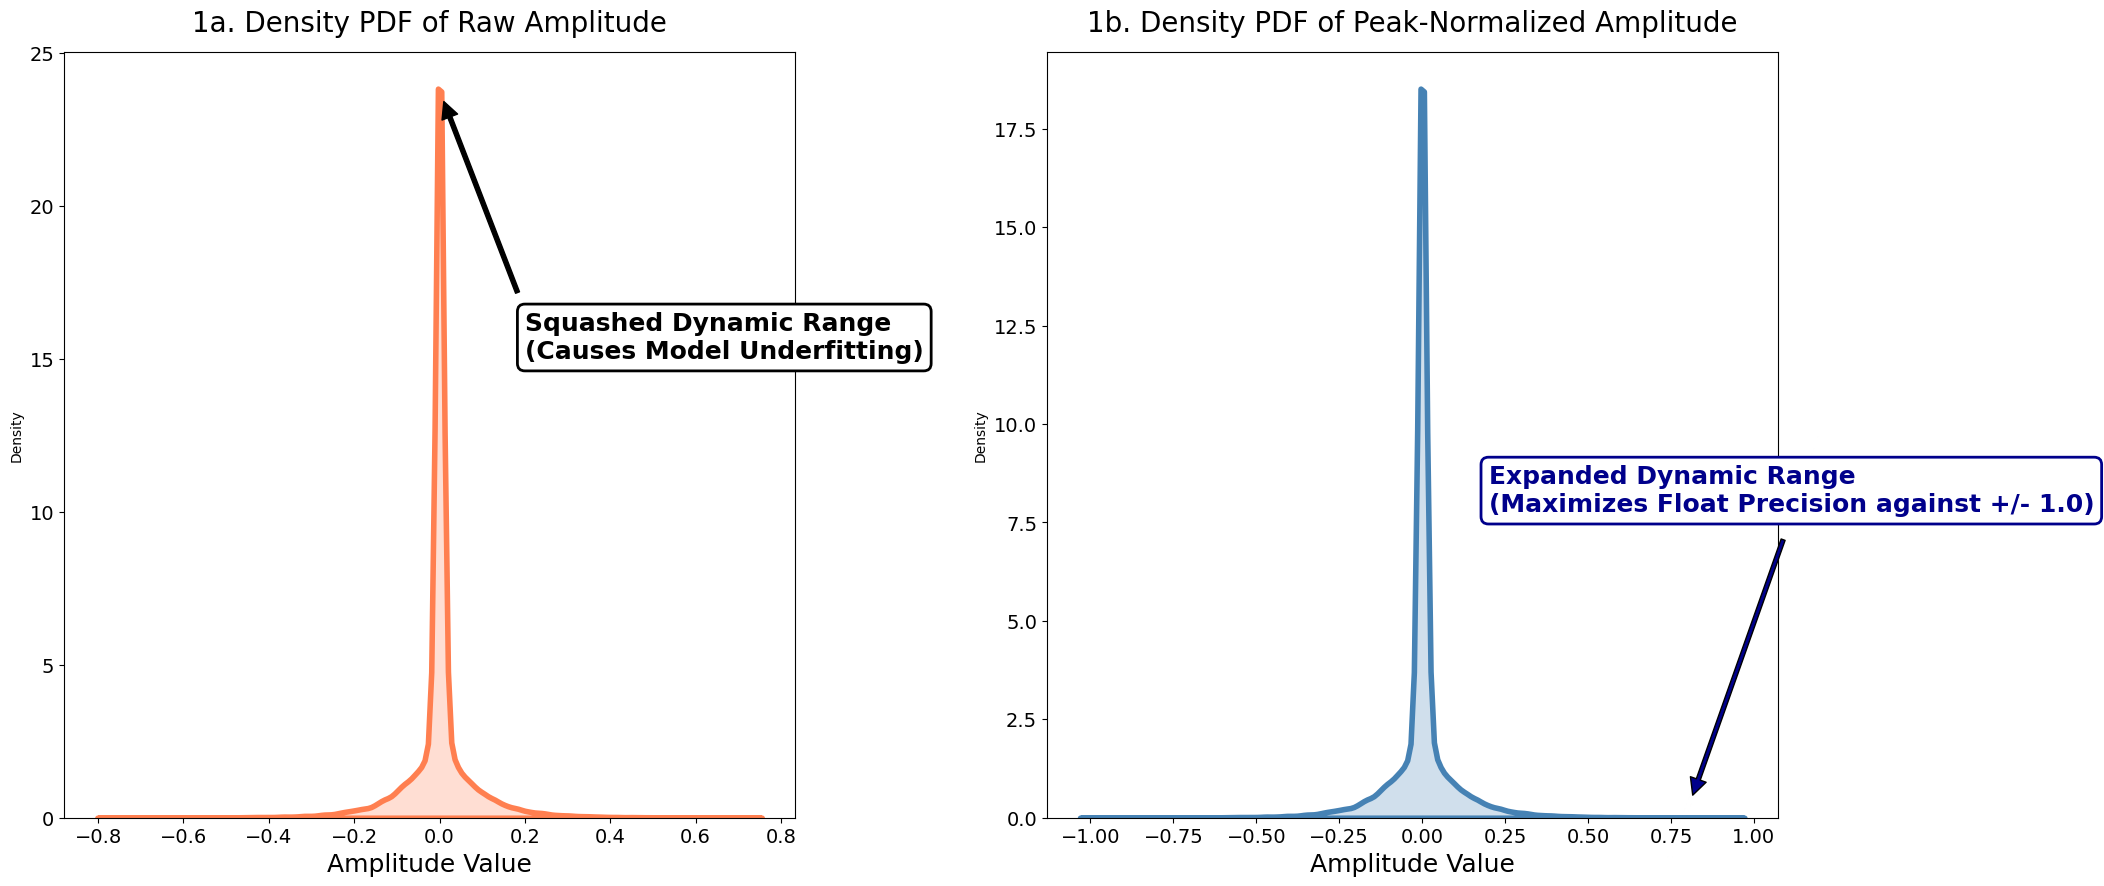

In [2]:
file_path = discover_audio_files(RAW_DIR)[0][0]
y_raw, sr = librosa.load(file_path, sr=16000)
y_norm = librosa.util.normalize(y_raw)

fig, axes = plt.subplots(1, 2, figsize=(22, 10))
plt.rcParams.update({"font.size": 16})

sns.kdeplot(y_raw, fill=True, color="coral", ax=axes[0], lw=4)
axes[0].set_title("1a. Density PDF of Raw Amplitude", fontsize=20, pad=15)
axes[0].set_xlabel("Amplitude Value", fontsize=18)
axes[0].tick_params(labelsize=14)

# ANNOTATION 1A
y_max_raw = axes[0].get_ylim()[1]
axes[0].annotate("Squashed Dynamic Range\n(Causes Model Underfitting)", 
            xy=(0.0, y_max_raw * 0.95), xytext=(0.2, y_max_raw * 0.6), 
            arrowprops=dict(facecolor="black", shrink=0.05, width=3, headwidth=12), 
            fontsize=18, fontweight="bold", color="black", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=2))

sns.kdeplot(y_norm, fill=True, color="steelblue", ax=axes[1], lw=4)
axes[1].set_title("1b. Density PDF of Peak-Normalized Amplitude", fontsize=20, pad=15)
axes[1].set_xlabel("Amplitude Value", fontsize=18)
axes[1].tick_params(labelsize=14)

# ANNOTATION 1B
y_max_norm = axes[1].get_ylim()[1]
axes[1].annotate("Expanded Dynamic Range\n(Maximizes Float Precision against +/- 1.0)", 
            xy=(0.8, 0.2), xytext=(0.2, y_max_norm * 0.4), 
            arrowprops=dict(facecolor="darkblue", shrink=0.05, width=3, headwidth=12), 
            fontsize=18, fontweight="bold", color="darkblue", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkblue", lw=2))

plt.tight_layout(pad=3.0)
plt.show()

**Advanced Interpretation:** The raw audio PDF (1a) is dangerously squeezed around 0. By dividing by the absolute max (Peak Normalization), we physically expand the true signal to fully utilize the [-1, 1] float space (1b).

### 2. Algorithmic Silence Trimming (Threshold Overlay)

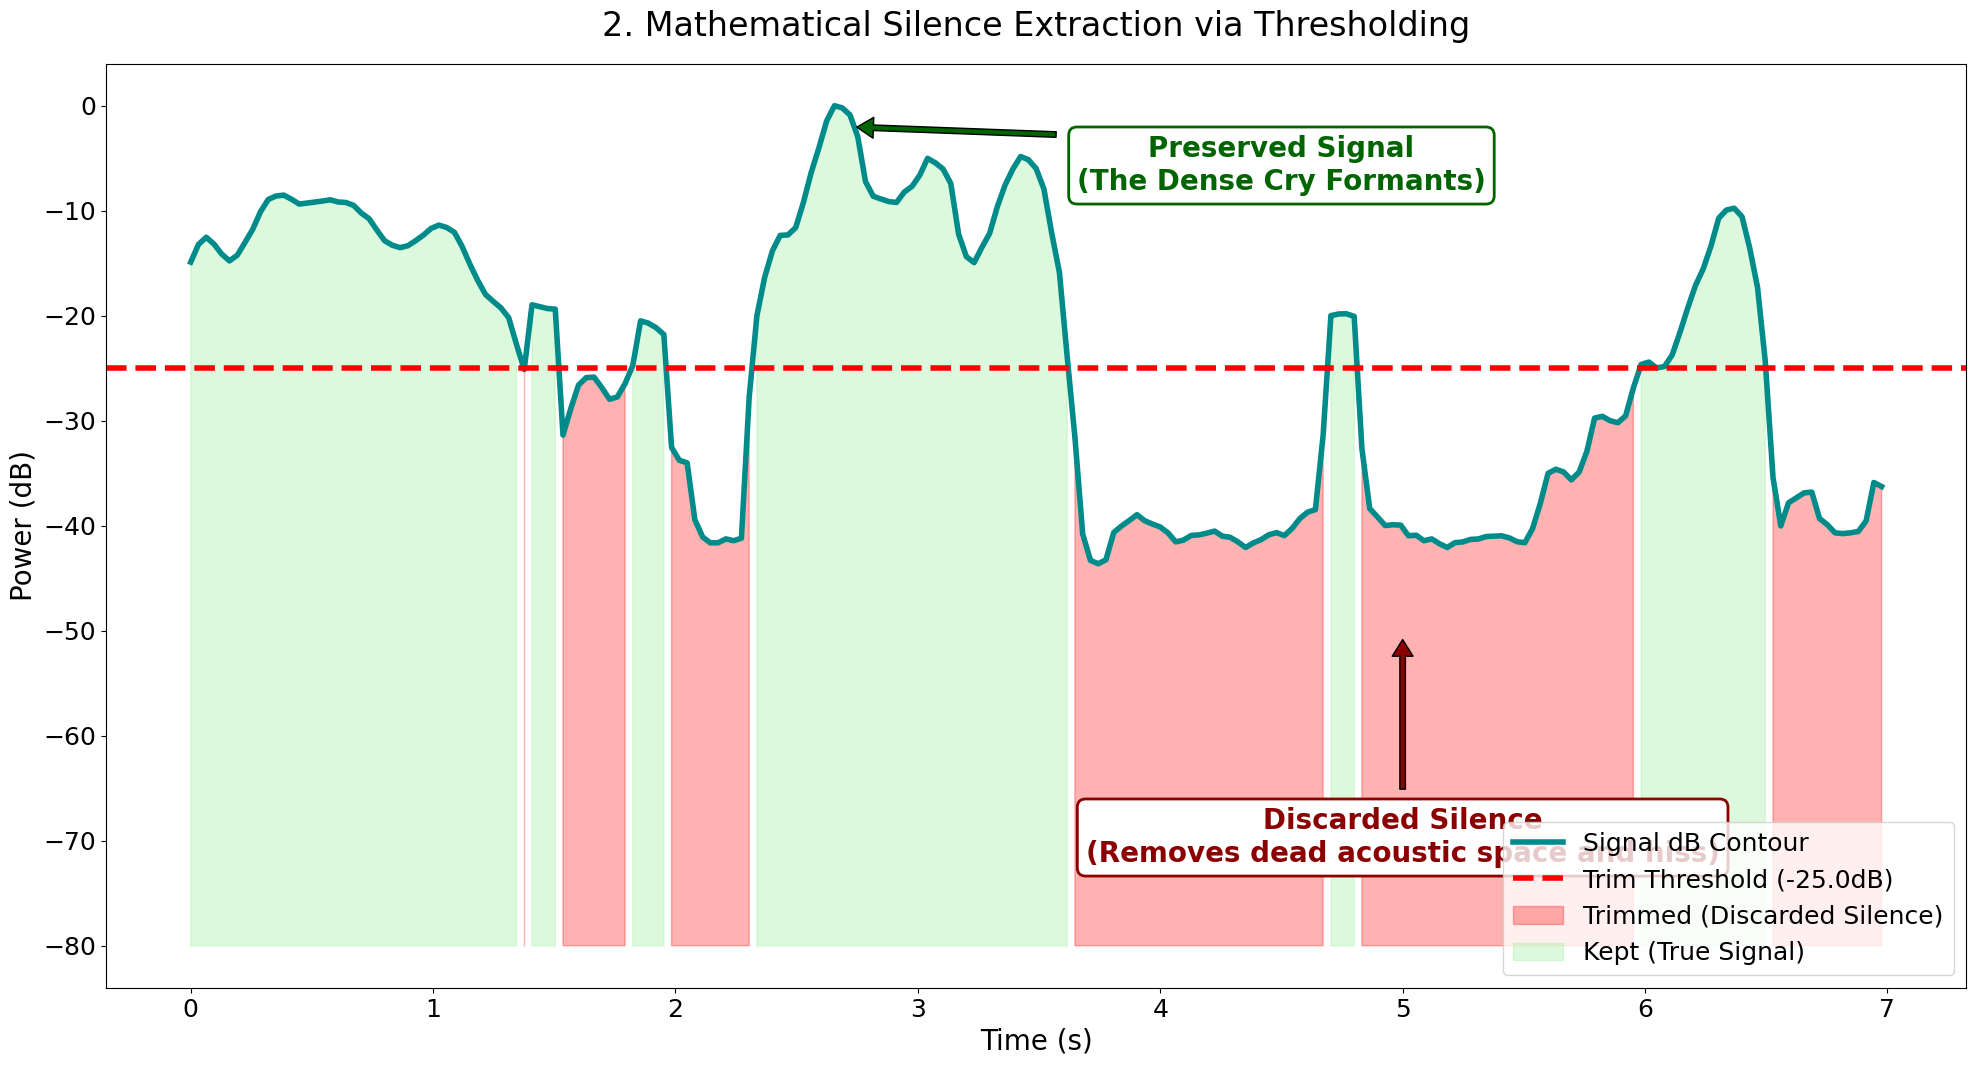

In [3]:
rms = librosa.feature.rms(y=y_norm)[0]
rms_db = librosa.amplitude_to_db(rms, ref=np.max)
times_rms = librosa.frames_to_time(range(len(rms_db)), sr=sr)
threshold_db = -25.0 

fig, ax = plt.subplots(figsize=(24, 12))
ax.plot(times_rms, rms_db, color="darkcyan", lw=4, label="Signal dB Contour")
ax.axhline(threshold_db, color="red", linestyle="--", lw=4, label=f"Trim Threshold ({threshold_db}dB)")
trim_mask = rms_db < threshold_db
ax.fill_between(times_rms, -80, rms_db, where=trim_mask, color="red", alpha=0.3, label="Trimmed (Discarded Silence)")
ax.fill_between(times_rms, -80, rms_db, where=~trim_mask, color="lightgreen", alpha=0.3, label="Kept (True Signal)")

ax.set_title("2. Mathematical Silence Extraction via Thresholding", fontsize=24, pad=20)
ax.set_ylabel("Power (dB)", fontsize=20)
ax.set_xlabel("Time (s)", fontsize=20)
ax.tick_params(labelsize=18)
ax.legend(loc="lower right", fontsize=18)

# ANNOTATION 2A: Moving to the right-side massive red block so it never overlaps the left-side green initial block
ax.annotate("Discarded Silence\n(Removes dead acoustic space and hiss)", 
            xy=(5.0, -50), xytext=(5.0, -72), 
            arrowprops=dict(facecolor="darkred", shrink=0.05, width=4, headwidth=15), 
            fontsize=20, fontweight="bold", color="darkred", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkred", lw=2))

# ANNOTATION 2B: Pointing directly to the absolute very top of the green mountain peak at t=2.7
ax.annotate("Preserved Signal\n(The Dense Cry Formants)", 
            xy=(2.7, -2), xytext=(4.5, -8), 
            arrowprops=dict(facecolor="darkgreen", shrink=0.05, width=4, headwidth=15), 
            fontsize=20, fontweight="bold", color="darkgreen", ha="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="darkgreen", lw=2))

plt.show()

### 3. Executing the Batch Standardization

In [4]:
print("Engaging standard preprocessing matrix...")
results = process_dataset(input_dir=RAW_DIR, output_dir=CLEANED_DIR)
print(f"Standardized {len(results)} files to {CLEANED_DIR}")

Engaging standard preprocessing matrix...


Processing belly_pain:   0%| | 

Processing belly_pain:   1%| | 

Processing belly_pain:  12%| | 

Processing belly_pain:  25%|▎| 

...

Processing tired:  57%|▌| 78/13

Processing tired:  71%|▋| 97/13

Processing tired:  84%|▊| 114/1

Processing tired:  96%|▉| 130/1

Standardized 1054 files to /Users/sainathmeesala/Desktop/Infant-State-Recognition-System/data/cleaned
